# The Cost of Discretion

## What public FIA data can—and cannot—establish about Formula 1 stewarding, 2018–2025

**Oversight report | Python, Jupyter, SQL/DuckDB | Evidence frozen through the 2025 season**

The central finding is methodological and substantive: **a nominal sanction and its realized
competitive burden are not the same quantity**. In the independently reviewed pilot, the same
five-second sanction changed a podium and six points in one case and changed no classification
position in another. A served ten-second penalty could not be converted honestly into a finishing
counterfactual, while a delayed grid penalty had an exact starting-grid effect but an unknowable
race-result effect.

That distinction matters for fairness, but it does not prove that a decision was wrong. FIA
stewards judge conduct and responsibility; penalties are not necessarily designed to compensate
the affected driver. The report therefore keeps **decision consistency**, **sanction burden**, and
**victim harm** as separate evidence dimensions.

The full-corpus pipeline is complete enough to audit the evidence system and diagnose study design,
but not to publish a league-wide fairness or nationality effect: all substantive outcome rows remain
blocked from reporting until independent review is complete. This notebook treats that boundary as
a result, not as missing fine print.

In [1]:
# ruff: noqa: E402
import os
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".jupyter" / "mplconfig"))

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from f1stewards.config import load_outcome_model_spec
from f1stewards.model_validation import (
    nationality_overlap_diagnostics,
    simulate_nationality_power,
)

DB_PATH = ROOT / "data" / "processed" / "f1_stewarding.duckdb"
PILOT = ROOT / "data" / "manual" / "reconciled" / "pilot-41f4502411c2"
GENERATED = ROOT / "reports" / "generated"
GENERATED.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
COLORS = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 120)

## Executive decision

The evidence supports four decisions:

1. **Do not use penalty seconds alone as a fairness measure.** Application timing, classification
   gaps, repair needs, retirement, and delayed sanctions determine who actually paid.
2. **Do not publish a British-bias estimate from the present design.** Outcome-free diagnostics show
   useful overlap but inadequate power for subtle effects, before the human-review gate is even met.
3. **Use the full corpus as a controlled review system, not as released outcome data.** Source
   coverage is complete; independent full-corpus verification is not.
4. **Ask the FIA for structured, versioned decisions.** A machine-readable incident ID, roles,
   applicable guidance, sanction application, and correction lineage would make consistency and
   consequence audits materially more reliable.

## 1. Population and release status

,stage,count,interpretation
0,FIA archive records,9467,Official event-document inventory
1,Outcome labels,2003,Version-preserving outcome population
2,Live outcome PDFs,1984,Retrieved and parsed
3,Content-confirmed decisions,1952,One live decision seed each
4,Provisional primary candidates,348,Design diagnostics only
5,Reporting-eligible adjudications,0,Substantive release gate


,control,status,observed,expected
0,workspace_integrity,pass,19,19
1,document_dispositions_complete,fail,0,2003
2,selected_candidate_panel_identity_complete,pass,0,0
3,adjudication_coding_complete,fail,0,1952
4,exclusion_qa_complete,fail,0,486
5,final_primary_population_nonempty,fail,0,> 0
6,final_primary_accused_identity_complete,pass,0,0
7,final_primary_binary_outcome_complete,pass,0,0
8,analytical_release,fail,one or more fail,all prerequisite controls pass


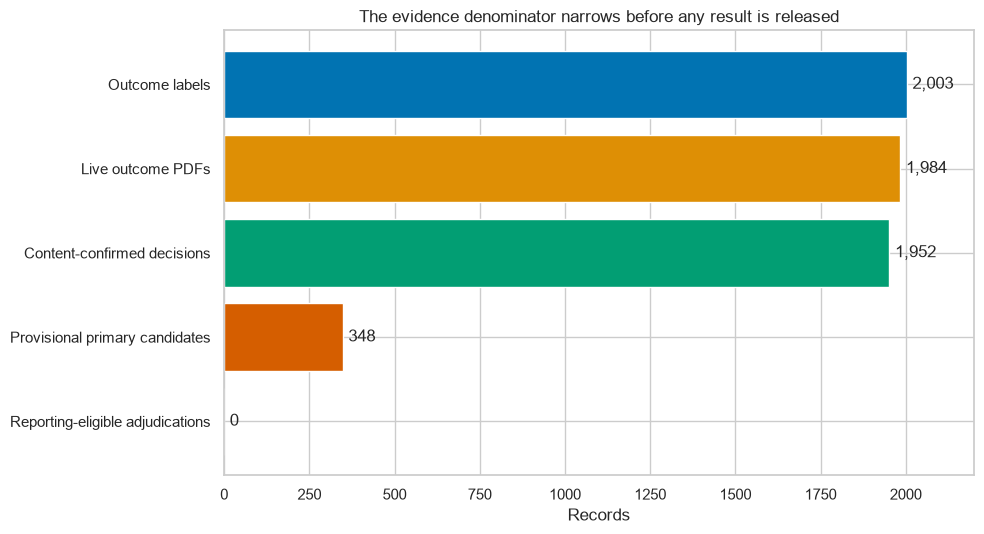

In [2]:
with duckdb.connect(str(DB_PATH), read_only=True) as connection:
    latest_build = connection.sql(
        """SELECT * FROM metadata.analysis_feature_builds
           ORDER BY built_at_utc DESC, feature_build_id DESC LIMIT 1"""
    ).df().iloc[0]
    controls = connection.sql(
        """SELECT control, status, observed, expected
           FROM analysis.feature_release_controls
           WHERE feature_build_id = ? ORDER BY control_order""",
        params=[latest_build["feature_build_id"]],
    ).df()
    features = connection.sql(
        """SELECT * FROM analysis.v_latest_adjudication_features
           ORDER BY adjudication_instance_id"""
    ).df()

flow = pd.DataFrame(
    {
        "stage": [
            "FIA archive records",
            "Outcome labels",
            "Live outcome PDFs",
            "Content-confirmed decisions",
            "Provisional primary candidates",
            "Reporting-eligible adjudications",
        ],
        "count": [
            9_467,
            2_003,
            1_984,
            1_952,
            len(features),
            int(features["reporting_eligible"].sum()),
        ],
        "interpretation": [
            "Official event-document inventory",
            "Version-preserving outcome population",
            "Retrieved and parsed",
            "One live decision seed each",
            "Design diagnostics only",
            "Substantive release gate",
        ],
    }
)
assert flow["count"].tolist() == [9467, 2003, 1984, 1952, 348, 0]
assert latest_build["release_status"] == "blocked_pending_human_review"
display(flow)
display(controls)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_flow = flow.iloc[1:].copy()
bars = ax.barh(plot_flow["stage"], plot_flow["count"], color=COLORS[:5])
ax.invert_yaxis()
ax.set(title="The evidence denominator narrows before any result is released", xlabel="Records")
ax.bar_label(bars, labels=[f"{value:,}" for value in plot_flow["count"]], padding=4)
ax.set_xlim(0, 2200)
plt.tight_layout()
fig.savefig(GENERATED / "population_flow.png", dpi=180, bbox_inches="tight")
plt.show()

All 173 completed championship events are covered. The archive layer preserves 2,003 outcome
labels, including corrected and recalled versions; 1,952 live records are confirmed steward
decisions. The analytical feature layer contains 348 provisional Race/Sprint candidates across 131
events, but **zero rows are reporting-eligible**. The release controls fail closed because full
document disposition, adjudication coding, and the 486-row exclusion audit have not received
independent review.

This means the project can report inventory, data quality, pipeline behavior, reviewed pilot cases,
and outcome-free design diagnostics. It cannot report league-wide sanction rates, anomaly rankings,
guideline departure rates, or nationality effects as findings.

## 2. Exploratory data analysis: what the candidate set contains

,incident_family,candidate_adjudications,incident_family_label
0,causing_collision,235,Causing Collision
1,gaining_advantage_off_track,54,Gaining Advantage Off Track
2,forcing_off_track,43,Forcing Off Track
3,unsafe_rejoin,8,Unsafe Rejoin
4,multiple_defensive_moves,6,Multiple Defensive Moves
5,moving_under_braking,2,Moving Under Braking


,season,candidate_adjudications
0,2018,54
1,2019,44
2,2020,18
3,2021,30
4,2022,46
5,2023,39
6,2024,54
7,2025,63


,feature_label_status,population_status,rows
0,incomplete_human_coding,incomplete_human_coding,174
1,incomplete_human_coding,source_coded_primary_pending_human,174


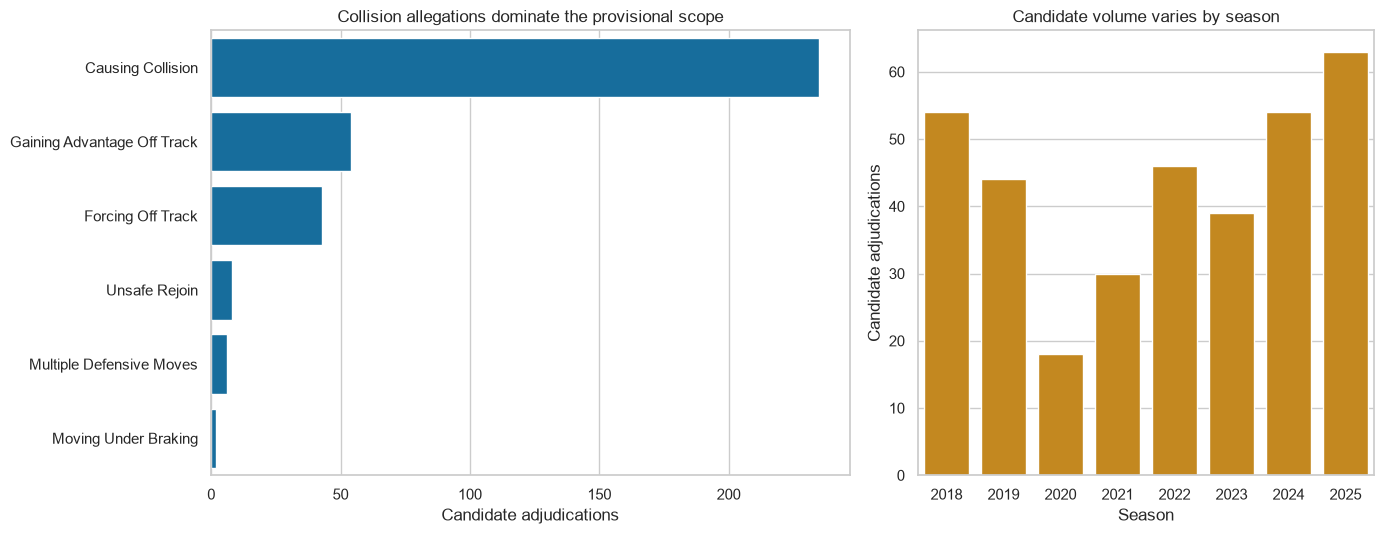

In [3]:
family_counts = (
    features.groupby("incident_family", dropna=False)
    .size()
    .rename("candidate_adjudications")
    .sort_values(ascending=False)
    .reset_index()
)
family_counts["incident_family_label"] = (
    family_counts["incident_family"].str.replace("_", " ").str.title()
)
season_counts = features.groupby("season").size().rename("candidate_adjudications").reset_index()
label_counts = (
    features.groupby(["feature_label_status", "population_status", "feature_provenance"])
    .size().rename("rows").reset_index()
)
display(family_counts)
display(season_counts)
display(label_counts[["feature_label_status", "population_status", "rows"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.4, 1]})
sns.barplot(
    data=family_counts,
    y="incident_family_label",
    x="candidate_adjudications",
    color=COLORS[0],
    ax=axes[0],
)
axes[0].set(
    title="Collision allegations dominate the provisional scope",
    xlabel="Candidate adjudications",
    ylabel="",
)
sns.barplot(
    data=season_counts,
    x="season",
    y="candidate_adjudications",
    color=COLORS[1],
    ax=axes[1],
)
axes[1].set(
    title="Candidate volume varies by season",
    xlabel="Season",
    ylabel="Candidate adjudications",
)
plt.tight_layout()
fig.savefig(GENERATED / "provisional_candidate_composition.png", dpi=180, bbox_inches="tight")
plt.show()

The candidate set contains 235 collision adjudications, 54 gaining-advantage cases, 43 forcing-off-
track cases, and 16 cases across the three smaller primary families. Twenty-five rows retain more
than one affected driver, so the model uses a separate driver-role bridge rather than forcing every
incident into a two-car shape. Half the rows now contain a completed source-coding pass and half
remain machine-assisted; every row is still pending independent verification.

The plots describe workload and case mix only. Outcome rates are intentionally not shown as report
findings because provisional labels could turn parser behavior into a false stewarding trend.

## 3. Nationality: diagnose the design before estimating an effect

,value
rows,348
events,131
exposed_rows,44
unexposed_rows,304
exposure_prevalence,0.126437
propensity_auc,0.705181
propensity_min,0.01
propensity_max,0.618251
common_support_lower,0.018238
common_support_upper,0.368474


,baseline_probability,target_risk_difference,target_exposure_log_odds,repetitions,successful_fits,successful_fit_fraction,simulation_fit_status,detection_power,target_power,power_target_met,monte_carlo_standard_error,median_estimated_log_odds,median_cluster_robust_se,exposed_rows,unexposed_rows,event_clusters,event_random_intercept_sd,interpretation_status
0,0.5,0.05,0.200671,500,500,1.000,stable,0.092,0.8,False,0.012926,0.212235,0.354761,44,304,131,0.35,design_simulation_not_effect_estimate
1,0.5,0.10,0.405465,500,500,1.000,stable,0.182,0.8,False,0.017255,0.418464,0.356355,44,304,131,0.35,design_simulation_not_effect_estimate
2,0.5,0.15,0.619039,500,500,1.000,stable,0.436,0.8,False,0.022177,0.652742,0.365617,44,304,131,0.35,design_simulation_not_effect_estimate
3,0.5,0.20,0.847298,500,500,1.000,stable,0.606,0.8,False,0.021852,0.840671,0.377859,44,304,131,0.35,design_simulation_not_effect_estimate
4,0.7,0.05,0.251314,500,500,1.000,stable,0.082,0.8,False,0.012270,0.242856,0.395914,44,304,131,0.35,design_simulation_not_effect_estimate
5,0.7,0.10,0.538997,500,500,1.000,stable,0.258,0.8,False,0.019567,0.559129,0.427577,44,304,131,0.35,design_simulation_not_effect_estimate
6,0.7,0.15,0.887303,500,498,0.996,stable,0.528,0.8,False,0.022326,0.935198,0.471673,44,304,131,0.35,design_simulation_not_effect_estimate
7,0.7,0.20,1.349927,500,496,0.992,stable,0.788,0.8,False,0.018279,1.414463,0.540832,44,304,131,0.35,design_simulation_not_effect_estimate


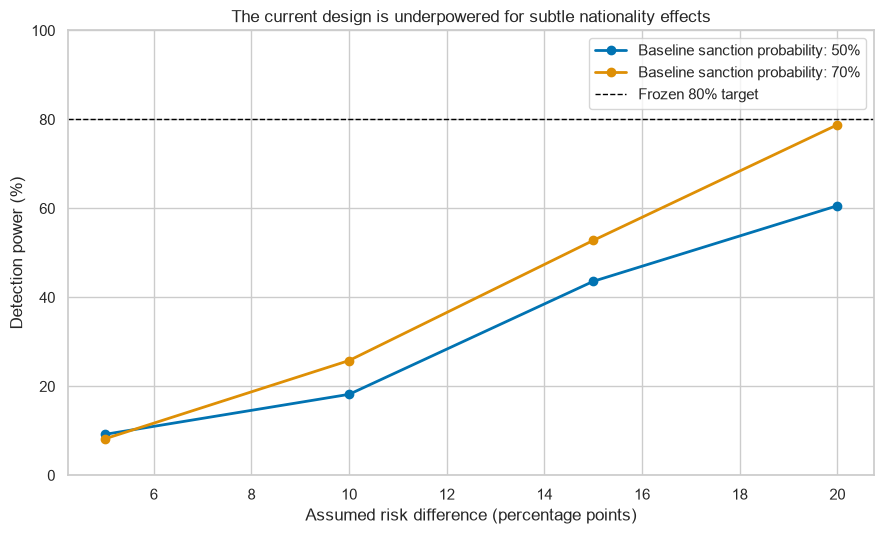

In [4]:
design_features = features.drop(columns=["sanction_outcome"]).copy()
spec = load_outcome_model_spec()
overlap = nationality_overlap_diagnostics(design_features, spec)
power = simulate_nationality_power(design_features, spec)
summary = overlap.summary.iloc[0]

display(overlap.summary.T.rename(columns={0: "value"}))
display(power)
assert int(summary["exposed_rows"]) == 44
assert int(summary["unexposed_rows"]) == 304
assert power["detection_power"].max() < 0.80

fig, ax = plt.subplots(figsize=(9, 5.5))
for index, (baseline, group) in enumerate(power.groupby("baseline_probability")):
    ax.plot(
        group["target_risk_difference"] * 100,
        group["detection_power"] * 100,
        marker="o",
        linewidth=2,
        color=COLORS[index],
        label=f"Baseline sanction probability: {baseline:.0%}",
    )
ax.axhline(80, color="black", linestyle="--", linewidth=1, label="Frozen 80% target")
ax.set(
    title="The current design is underpowered for subtle nationality effects",
    xlabel="Assumed risk difference (percentage points)",
    ylabel="Detection power (%)",
    ylim=(0, 100),
)
ax.legend(frameon=True)
plt.tight_layout()
fig.savefig(GENERATED / "nationality_power.png", dpi=180, bbox_inches="tight")
plt.show()

power.to_csv(GENERATED / "nationality_power.csv", index=False)
overlap.summary.to_csv(GENERATED / "nationality_overlap_summary.csv", index=False)

The outcome-free population has 44 British and 304 other accused-driver exposures. Estimated common
support is 97.4%, and overlap weighting reduces the largest absolute standardized difference from
0.526 to 0.040. That is encouraging for comparability, but it does not solve sample-size limits.

Across the frozen simulation grid, approximate detection power ranges from 8.2% to 78.8%. Even an
assumed 20-percentage-point difference at a 70% baseline misses the 80% target; 5–10-point effects
are far less detectable. **The correct nationality conclusion is “inconclusive,” not “no bias” and
not “bias.”** No observed sanction outcome was used in this diagnostic.

## 4. The reviewed pilot: sanction severity is not realized burden

,case,nominal sanction,application,realized sanction burden,affected-driver evidence
0,"Pérez → Norris, Abu Dhabi 2023",5 seconds + 2 points,added after race,P4→P2 without penalty; 6 points and podium,Norris P4→P5 next lap; 0.167 s relative swing
1,"Tsunoda → Colapinto, Austria 2025",10 seconds + 2 points,served during race,not mechanically estimable,no immediate place loss; possible damage alleged
2,"Colapinto → Piastri, Austria 2025",5 seconds + 1 point,added after race,0 positions; 0 points,forced off; seconds/win effect not estimable
3,"Antonelli → Verstappen, Austria 2025",3-grid places + 2 points,next event,exact P7→P10 start; race effect not estimable,confirmed incident-caused retirement


,count
affected-driver records,9
fault-established records,4
confirmed damage records,2
alleged damage records,1
incident-caused retirements,1
incident-responsive repair stops,0
observed positive position losses,3
persistent pace estimates released,0


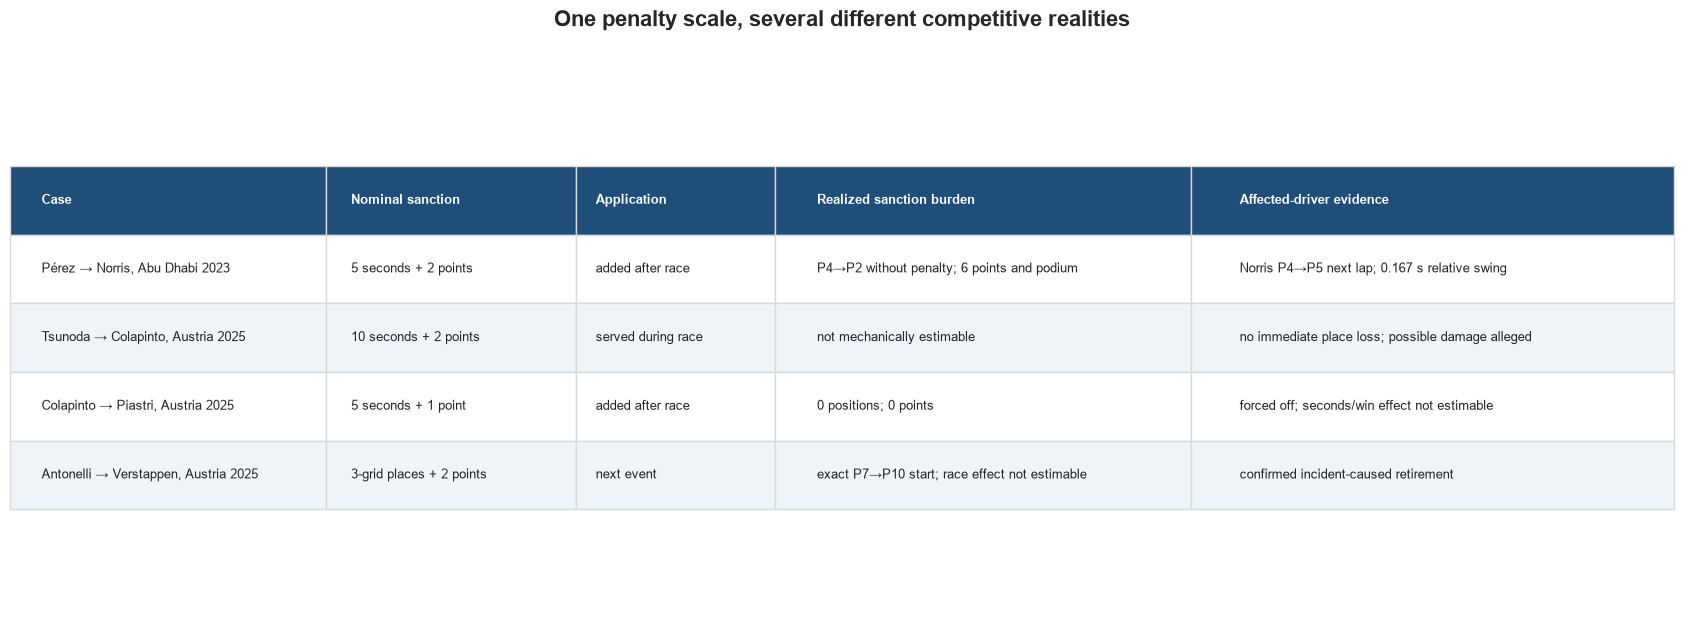

In [5]:
adjudications = pd.read_csv(PILOT / "adjudications.csv")
impacts = pd.read_csv(PILOT / "impact_assessments.csv")
harms = pd.read_csv(PILOT / "harm_assessments.csv")
cross_event = pd.read_csv(PILOT / "cross_event_sanction_effects.csv")

assert len(adjudications) == 9
assert len(impacts) == 4
assert len(harms) == 9
assert set(adjudications["review_status"]) == {"double_coded"}
assert set(impacts["review_status"]) == {"double_coded"}
assert set(harms["review_status"]) == {"double_coded"}

pilot_matrix = pd.DataFrame(
    [
        {
            "case": "Pérez → Norris, Abu Dhabi 2023",
            "nominal sanction": "5 seconds + 2 points",
            "application": "added after race",
            "realized sanction burden": "P4→P2 without penalty; 6 points and podium",
            "affected-driver evidence": "Norris P4→P5 next lap; 0.167 s relative swing",
        },
        {
            "case": "Tsunoda → Colapinto, Austria 2025",
            "nominal sanction": "10 seconds + 2 points",
            "application": "served during race",
            "realized sanction burden": "not mechanically estimable",
            "affected-driver evidence": "no immediate place loss; possible damage alleged",
        },
        {
            "case": "Colapinto → Piastri, Austria 2025",
            "nominal sanction": "5 seconds + 1 point",
            "application": "added after race",
            "realized sanction burden": "0 positions; 0 points",
            "affected-driver evidence": "forced off; seconds/win effect not estimable",
        },
        {
            "case": "Antonelli → Verstappen, Austria 2025",
            "nominal sanction": "3-grid places + 2 points",
            "application": "next event",
            "realized sanction burden": "exact P7→P10 start; race effect not estimable",
            "affected-driver evidence": "confirmed incident-caused retirement",
        },
    ]
)
display(pilot_matrix)

harm_summary = pd.Series(
    {
        "affected-driver records": len(harms),
        "fault-established records": int(
            (harms["responsibility_status"] == "fault_established").sum()
        ),
        "confirmed damage records": int((harms["damage_evidence"] == "confirmed").sum()),
        "alleged damage records": int((harms["damage_evidence"] == "alleged").sum()),
        "incident-caused retirements": int((harms["retirement_status"] == "incident_caused").sum()),
        "incident-responsive repair stops": int((harms["repair_stop_required"] == "yes").sum()),
        "observed positive position losses": int((harms["net_positions_lost_observed"] > 0).sum()),
        "persistent pace estimates released": int(
            harms["persistent_loss_seconds_estimate"].notna().sum()
        ),
    },
    name="count",
)
display(harm_summary.to_frame())

table_fig, table_ax = plt.subplots(figsize=(17, 6.5))
table_ax.axis("off")
wrapped = pilot_matrix.copy()
wrapped.columns = [
    "Case",
    "Nominal sanction",
    "Application",
    "Realized sanction burden",
    "Affected-driver evidence",
]
table = table_ax.table(
    cellText=wrapped.values,
    colLabels=wrapped.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.19, 0.15, 0.12, 0.25, 0.29],
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1, 3.6)
for (row, _col), cell in table.get_celld().items():
    cell.set_edgecolor("#d9d9d9")
    if row == 0:
        cell.set_facecolor("#1f4e79")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#eef4f8")
table_ax.set_title(
    "One penalty scale, several different competitive realities",
    fontsize=16,
    weight="bold",
    pad=18,
)
plt.tight_layout()
table_fig.savefig(GENERATED / "pilot_harm_sanction_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

The purposive pilot covers nine adjudications in Austria 2019, Abu Dhabi 2023, and Austria
2025; all 26 adjudication, impact, harm, location, relation, and cross-event review targets
were independently agreed and reconciled.

Its key lesson is not that one of these penalties was necessarily unfair. It is that a five-second
number does not identify the actual burden:

- Pérez's post-race five seconds mechanically cost two places, six points, and a podium.
- Colapinto's post-race five seconds changed no place and no points.
- Tsunoda's served ten seconds altered strategy and traffic, so final-time subtraction would be
  false precision.
- Antonelli's delayed penalty moved his next start from P7 to P10 exactly, but the wet-race result
  remained confounded.

The victim side is also multidimensional. Four pilot records establish counterparty fault; one
contains an incident-caused retirement, one an observed next-lap position loss, one possible damage
without immediate place loss, and one an off-track excursion whose seconds could not be isolated.
No persistent per-lap damage estimate passed the clean-lap evidence rule. Severe harm is not itself
proof of fault, and a conduct-based penalty is not automatically a restorative payment.

## 5. Public-guideline audit: a bounded pilot finding

In [6]:
guideline_pilot = adjudications.loc[
    adjudications["guideline_regime"] == "public_driving_and_penalty_guidelines",
    ["adjudication_id", "incident_family", "outcome_family", "conformance_status", "coding_notes"],
]
display(guideline_pilot)
display(guideline_pilot["conformance_status"].value_counts().rename("cases").to_frame())
assert len(guideline_pilot) == 5
assert set(guideline_pilot["conformance_status"]) == {"conformant", "mitigated"}

,adjudication_id,incident_family,outcome_family,conformance_status,coding_notes
4,adj-2025-aut-r31-t4-22,causing_collision,time_penalty,conformant,Official reason says Car 22 was fully at fault and did not earn the corner; 2 points are within the published 3-poin...
5,adj-2025-aut-r4-t3-43,forcing_off_track,no_further_action,conformant,Official reason finds Car 87 lacked outside-overlap priority so Car 43 could use the regular racing line; lap is sup...
6,adj-2025-aut-r54-t34-43,forcing_off_track,time_penalty,mitigated,Decision explicitly mitigates because Car 22 obscured Car 81; race-control evidence places the event on global lap 5...
7,adj-2025-aut-r1-t3-12,causing_collision,grid_penalty,conformant,Decision says Car 12 was fully at fault but records evasive action and a non-blatant move; grid penalty was used bec...
8,adj-2025-aut-r15-t3-22,forcing_off_track,no_further_action,conformant,Doc 46 appears to replace unavailable recalled Doc 39; the reason finds all inside-overtake requirements satisfied a...


,cases
conformance_status,
conformant,4
mitigated,1


All five reviewed 2025 Austrian pilot decisions matched the public baseline/rule outcome or recorded
explicit mitigation: four were coded conformant and one mitigated. This demonstrates that the
method can distinguish baseline, mitigation, and departure. It is **not** a 2025 league-wide
conformance rate; the full-year mapping has not passed independent review.

## 6. Conclusions and recommendations

### Conclusion

The public record does not currently support a defensible conclusion that F1 stewarding was
systematically inconsistent or nationally biased from 2018–2025. That statement is about evidence
strength, not an acquittal: full-corpus labels are unreleased, non-referrals are unobserved, panel
nationalities remain incomplete, and the British-driver contrast is underpowered for subtle
effects.

The report does support a narrower and useful conclusion: **competitive fairness cannot be audited
with the penalty column alone.** Any serious comparison must preserve at least four linked facts:
the responsibility finding, nominal sanction, realized sanction burden, and affected-driver harm.
The reviewed pilot shows these dimensions diverging even when nominal penalties look similar.

### Recommendations

1. **Publish structured decisions.** Add stable incident/adjudication IDs, accused and affected
   roles, session/lap/turn, finding, sanction, application timing, and version status.
2. **Version the guidance.** Publish the exact guideline text effective at each event and identify
   the baseline plus written aggravating or mitigating factors in each decision.
3. **Report consequence dimensions separately.** Keep seconds, grid positions, classification
   positions, points, repair, damage, and retirement separate; do not collapse them into a single
   fairness score.
4. **Preserve the referral boundary.** Acknowledge that formal decisions can measure treatment only
   among referred cases. A complete fairness audit also needs referral/non-referral data.
5. **Use models as triage.** Calibrated residuals should prioritize comparable cases for evidence
   review, never declare a steward wrong automatically.
6. **Release conservatively.** Keep nationality and guideline findings descriptive or inconclusive
   until independent review, overlap, power, and sensitivity gates pass.

### Evidence grades

| Finding | Grade | Release decision |
|---|---|---|
| 2018–2025 source inventory and lineage | A | Reportable |
| Reviewed pilot mechanical impact arithmetic | A | Reportable for pilot cases |
| Reviewed pilot harm and guideline case audit | D | Case-study evidence; no population rate |
| Full-corpus consistency and anomaly results | U | Withheld pending independent review |
| British-driver association | U | Inconclusive; effect not estimated |
| Panel-nationality association | U | Withheld pending complete source evidence |

The practical accomplishment is an auditable data product: source-preserving ETL, typed analytical
models, DuckDB SQL, FastF1 enrichment, content-addressed review lineage, validation controls,
executable Jupyter analysis, a self-service evidence console, and a credential-free Snowflake/
Snowsight deployment package. The same controls that make the project slower to sensationalize are
what make it useful for oversight work.

## Technical appendix: reproducibility and limitations

- **Population:** 173 completed F1 championship events, 2018–2025; Race and Sprint primary sessions.
- **Primary unit:** one accused-driver adjudication; multi-car affected roles retained separately.
- **Authorities:** FIA decisions and classifications; FastF1 used for timing enrichment, not fault.
- **Storage/query:** typed Parquet exports and DuckDB schemas; Snowflake/Snowsight SQL package is
  locally validated but not claimed as remotely deployed.
- **Validation:** 19 editable-workspace controls, schema contracts, SQL integrity checks,
  test suite, checksum manifests, and content-addressed reconciliation.
- **Referral limitation:** incidents never formally referred are outside the denominator.
- **Human-review limitation:** zero of the 4,441 full-corpus review targets meet the independent
  completion status; the 486-row stratified exclusion audit is still pending.
- **Power limitation:** the provisional nationality design is not powered for subtle associations.
- **Counterfactual limitation:** served penalties, repair effects, and race outcomes are not
  obtained by naive time subtraction.
- **Causal limitation:** observed position/time changes do not prove the no-incident outcome.

Rebuild the feature layer with `f1stewards build-analysis-features`, execute notebooks 04–06, run
`pytest` and `ruff check`, and inspect `analysis.feature_release_controls` before interpreting any
substantive table. The report intentionally fails closed when those controls do not authorize a
claim.